<a href="https://colab.research.google.com/github/Neeraj-P-Raju/AIML-internship/blob/main/Tensorflow_lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.20.0


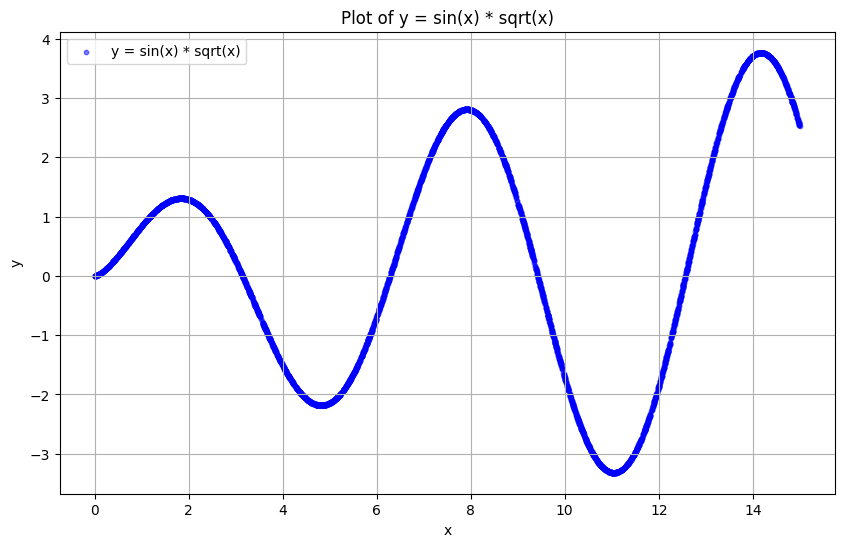

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)

SAMPLES = 5000
x_values = np.random.uniform(low=0, high=15, size=SAMPLES)
y_values = np.sin(x_values)*np.sqrt(x_values)
TRAIN_SPLIT = int(0.6 * SAMPLES)
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT)
x_train, x_validate, x_test = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_validate, y_test = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', alpha=0.5, s=10, label='y = sin(x) * sqrt(x)')
plt.title("Plot of y = sin(x) * sqrt(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


In [3]:
from tensorflow.keras import layers
import tensorflow as tf
# Initialization of ANN model
model = tf.keras.Sequential()
# Add 1 input layer and an hidden layer with 16 units to the model
model.add(layers.Dense(16, activation='relu', input_shape=(1,)))
# Add another hidden layer with 16 units
model.add(layers.Dense(16, activation='relu'))
# Add an output layer with 1 output unit
model.add(layers.Dense(1))

In [4]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history=model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_validate, y_validate))


Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.8943 - mae: 1.6787 - val_loss: 4.1445 - val_mae: 1.7628
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8793 - mae: 1.6787 - val_loss: 4.1322 - val_mae: 1.7617
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8659 - mae: 1.6728 - val_loss: 4.1028 - val_mae: 1.7452
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8327 - mae: 1.6578 - val_loss: 4.0624 - val_mae: 1.7302
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7946 - mae: 1.6408 - val_loss: 4.0186 - val_mae: 1.7079
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7431 - mae: 1.6207 - val_loss: 4.0267 - val_mae: 1.6868
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7051 - mae: 1.6006 - val_loss: 3.9152 - val_mae: 1.6655
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6567 - mae: 1.5814 - val_loss: 3.8630 - val_mae: 1.6480
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6136 - mae: 

In [5]:
predictions = model.predict(x_test)
model.save('my_model.h5')
import os

# If saved as HDF5
file_path = 'my_model.h5'
model_size_kb = os.path.getsize(file_path) / 1024
print(f"Model size: {model_size_kb:.2f} KB")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Model size: 27.51 KB


In [6]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
# Save to file
with open('arduino_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Check size
import os
model_size_kb = os.path.getsize('arduino_model.tflite') / 1024
print(f"TFLite model size: {model_size_kb:.2f} KB")

Saved artifact at '/tmp/tmprdmvizbg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140011529802896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140011529801360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140011529799056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140011529804624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140011529805776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140011529805008: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model size: 3.12 KB


In [7]:
import tensorflow as tf
import numpy as np

# --- Executing the .h5 Keras model ---
print("\n--- Executing Keras (.h5) model ---")
# Load the Keras model with compile=False to avoid deserialization issues
loaded_keras_model = tf.keras.models.load_model('my_model.h5', compile=False)

# Recompile the model with the original settings
loaded_keras_model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# Make predictions with the loaded Keras model
k_predictions = loaded_keras_model.predict(x_test)
print(f"Keras model predictions (first 5):\n{k_predictions[:5].flatten()}")

# --- Executing the .tflite model ---
print("\n--- Executing TensorFlow Lite (.tflite) model ---")
# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path='arduino_model.tflite')
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare input data for TFLite (it expects float32 and specific shape)
x_test_tflite = x_test.astype(np.float32).reshape(-1, 1)

tflite_predictions = []
for i in range(len(x_test_tflite)):
    input_data = x_test_tflite[i:i+1]
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    tflite_predictions.append(output_data[0])

tflite_predictions = np.array(tflite_predictions)

print(f"TFLite model predictions (first 5):\n{tflite_predictions[:5].flatten()}")

# Compare a few predictions (optional)
print("\n--- Comparison (Keras vs TFLite) ---")
for i in range(5):
    print(f"Sample {i}: Keras={k_predictions[i][0]:.4f}, TFLite={tflite_predictions[i][0]:.4f}")


--- Executing Keras (.h5) model ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Keras model predictions (first 5):
[-0.95935965  1.2492961   1.2693958   1.2638102   0.7909577 ]

--- Executing TensorFlow Lite (.tflite) model ---
TFLite model predictions (first 5):
[-0.95935965  1.2492961   1.2693961   1.26381     0.7909579 ]

--- Comparison (Keras vs TFLite) ---
Sample 0: Keras=-0.9594, TFLite=-0.9594
Sample 1: Keras=1.2493, TFLite=1.2493
Sample 2: Keras=1.2694, TFLite=1.2694
Sample 3: Keras=1.2638, TFLite=1.2638
Sample 4: Keras=0.7910, TFLite=0.7910


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [8]:
# Generate the header file
!echo "const unsigned char model[] = {" > /content/model.h
!cat arduino_model.tflite | xxd -i >> /content/model.h
!echo "};" >> /content/model.h